<img src="https://news.illinois.edu/files/6367/543635/116641.jpg" alt="University of Illinois" width="250"/>

## Closing the Amortization Gap in Bayesian Deep Generative Models ##
### STAT 546 Bayesian Machine Learning Project ###

Project submission by:
* Jordan Deklerk (deklerk3)

This project closely follows this [VAE tutorial](https://github.com/Jackson-Kang/Pytorch-VAE-tutorial/blob/master/01_Variational_AutoEncoder.ipynb) and gained considerable insight from this [github](https://github.com/AntixK/PyTorch-VAE). We mainly use the idea for the linear encoder and decoder and then add the ability to compare A-VI against F-VI and constant VI by adding a suite of additional functions. The goal of the project is to first see if A-VI can close the gap to F-VI in terms of the ELBO loss, and second, to illustrate the computational advantage of A-VI compared to F-VI and constant-VI.

## Imports

In [ ]:
%%capture
!pip install wandb ipywidgets

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import argparse
import time
import os
import wandb
import argparse

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import SVHN
from torchvision.datasets import CIFAR10
from torchvision.datasets import MNIST
from torchvision.datasets import FashionMNIST
from torch.optim import AdamW, Adam

from typing import Tuple

from tqdm import tqdm
import random

from ipywidgets import Widget
Widget.close_all()

In [ ]:
def get_args_parser():
    parser = argparse.ArgumentParser('Bayesian VAE', add_help=False)
    parser.add_argument('--dataset', default='MNIST', type=str, choices=['MNIST', 'CIFAR10', 'FashionMNIST', 'SVHN'],
                        help='dataset to use')
    parser.add_argument('--batch_size', default=10000, type=int,
                        help='batch size')
    parser.add_argument('--epochs', default=5000, type=int,
                        help='number of total epochs to run')
    parser.add_argument('--lr', default=1e-3, type=float,
                        help='initial learning rate')
    parser.add_argument('--weight_decay', default=1e-1, type=float,
                        help='weight decay')
    parser.add_argument('--z_dim', default=64, type=int,
                        help='z dimension')
    parser.add_argument('--like_dim', default=256, type=int,
                        help='likelihood dimension')
    parser.add_argument('--nn_widths', default=[1, 64, 128, 256], type=list,
                        help='neural network widths')
    parser.add_argument('--n_obs', default=10000, type=int,
                        help='number of observations')
    parser.add_argument('--mc_samples', default=100, type=int,
                        help='number of monte carlo samples')
    parser.add_argument('--seed', default=315, type=int,
                        help='seed')
    return parser

args, unknown = get_args_parser().parse_known_args()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Dataloader

In [ ]:
class CustomDatasetLoader:
    def __init__(self, dataset_name, dataset_path, batch_size, use_basic_transform=False, num_workers=8, pin_memory=True, img_size=32):
        self.dataset_name = dataset_name
        self.dataset_path = dataset_path
        self.batch_size = batch_size
        self.use_basic_transform = use_basic_transform
        self.num_workers = num_workers
        self.pin_memory = pin_memory
        self.img_size = img_size

        self.setup_transforms()
        self.load_dataset()

    def setup_transforms(self):
        if self.use_basic_transform:
            self.train_transform = self.val_transform = transforms.Compose([
                transforms.Resize((self.img_size, self.img_size)),
                transforms.ToTensor()
            ])
        elif self.dataset_name in ["CIFAR10", "SVHN"]:
            self.train_transform, self.val_transform = self.get_cifar10_svhn_transforms()
        else:
            self.train_transform = self.val_transform = transforms.Compose([transforms.ToTensor()])

    def get_cifar10_svhn_transforms(self):
        train_transform = transforms.Compose([
            transforms.TrivialAugmentWide(interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.PILToTensor(),
            transforms.ConvertImageDtype(torch.float),
            transforms.RandomErasing(p=0.1)
        ])
        val_transform = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.ToTensor()
        ])
        return train_transform, val_transform

    def load_dataset(self):
        if self.use_basic_transform:
            transform = transforms.Compose([
                transforms.ToTensor()
            ])
        else:
            if self.dataset_name in ["CIFAR10", "SVHN"]:
                transform = self.get_cifar10_svhn_transforms()
            else:
                transform = transforms.Compose([transforms.ToTensor()])

        if self.dataset_name == "CIFAR10":
            train_dataset = CIFAR10(self.dataset_path, train=True, download=True, transform=transform)
            test_dataset = CIFAR10(self.dataset_path, train=False, download=True, transform=transform)
        elif self.dataset_name == "SVHN":
            train_dataset = SVHN(self.dataset_path, split='train', download=True, transform=transform)
            test_dataset = SVHN(self.dataset_path, split='test', download=True, transform=transform)
        else:
            dataset_class = globals()[self.dataset_name]
            train_dataset = dataset_class(self.dataset_path, train=True, download=True, transform=transform)
            test_dataset = dataset_class(self.dataset_path, train=False, download=True, transform=transform)

        self.train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, pin_memory=self.pin_memory)
        self.test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=self.pin_memory)

## Visualize Sample Images

In [ ]:
def imshow(img, title=None):
    """Utility function to show an image using matplotlib."""
    npimg = img.numpy()
    plt.figure(figsize=(10, 5))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title is not None:
        plt.title(title)
    plt.show()

def visualize_dataset_images(dataloader, dataset_name, classes=None):
    """Visualize images for a given dataset."""
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    imshow(torchvision.utils.make_grid(images[:4]), title=f"Sample images from {dataset_name}")

    if classes is not None:
        labels = [classes[label] for label in labels[:4]]
        print("Labels:", labels)

Files already downloaded and verified
Files already downloaded and verified
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat


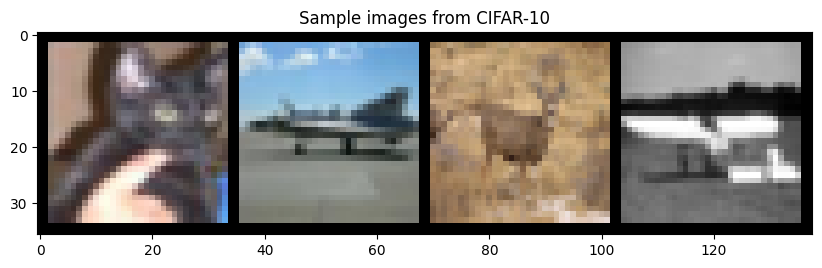

Labels: ['cat', 'airplane', 'deer', 'airplane']


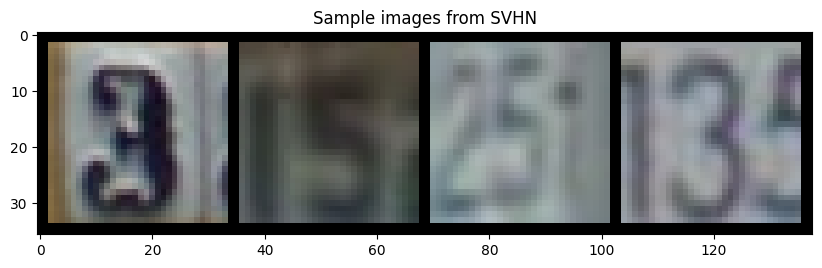

Labels: ['3', '5', '5', '3']


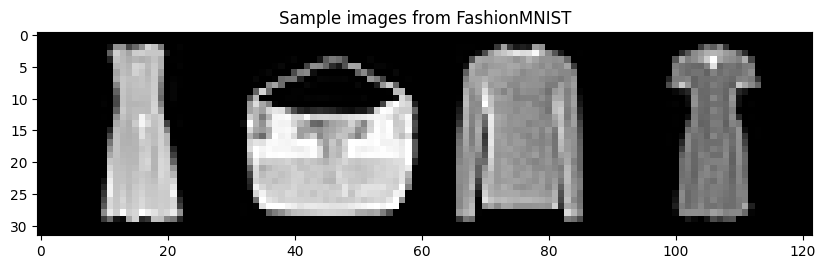

Labels: ['Dress', 'Bag', 'Pullover', 'Dress']


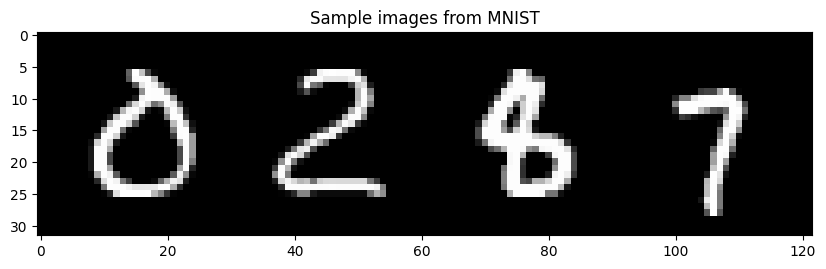

Labels: ['0', '2', '8', '7']


In [ ]:
cifar_loader = CustomDatasetLoader("CIFAR10", 'data', 128, use_basic_transform=True, img_size=32)
svhn_loader = CustomDatasetLoader("SVHN", 'data', 128, use_basic_transform=True, img_size=32)
fashion_mnist_loader = CustomDatasetLoader("FashionMNIST", 'data', 128, use_basic_transform=True, img_size=28)
mnist_loader = CustomDatasetLoader("MNIST", 'data', 128, use_basic_transform=True, img_size=28)


cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
svhn_classes = [str(i) for i in range(10)]
fashion_mnist_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
mnist_classes = [str(i) for i in range(10)]


visualize_dataset_images(cifar_loader.train_loader, "CIFAR-10", classes=cifar_classes)
visualize_dataset_images(svhn_loader.train_loader, "SVHN", classes=svhn_classes)
visualize_dataset_images(fashion_mnist_loader.train_loader, "FashionMNIST", classes=fashion_mnist_classes)
visualize_dataset_images(mnist_loader.train_loader, "MNIST", classes=mnist_classes)

## Config

In [ ]:
dataset_path = '~/datasets'

dataset_configs = {
    "MNIST": {"x_dim": 28 * 28, "hidden_dim": 400, "latent_dim": 200, "dataset": MNIST},
    "FashionMNIST": {"x_dim": 28 * 28, "hidden_dim": 400, "latent_dim": 200, "dataset": FashionMNIST},
    "CIFAR10": {"x_dim": 32 * 32 * 3, "hidden_dim": 128, "latent_dim": 100, "dataset": CIFAR10},
    "SVHN": {"x_dim": 32 * 32, "hidden_dim": 128, "latent_dim": 100, "dataset": SVHN},
}

transform = transforms.Compose([transforms.ToTensor()])
kwargs = {'num_workers': 4, 'pin_memory': True}

def get_dataset(data_set_name, dataset_path, transform, **kwargs):
    if data_set_name not in dataset_configs:
        raise ValueError(f"Unsupported dataset: {data_set_name}")

    config = dataset_configs[data_set_name]
    dataset_class = config["dataset"]

    if data_set_name == "SVHN":
        train_dataset = dataset_class(root=dataset_path, split='train', transform=transform, download=True)
        test_dataset = dataset_class(root=dataset_path, split='test', transform=transform, download=True)
    else:
        train_dataset = dataset_class(root=dataset_path, train=True, transform=transform, download=True)
        test_dataset = dataset_class(root=dataset_path, train=False, transform=transform, download=True)

    return train_dataset, test_dataset

train_dataset, test_dataset = get_dataset(args.dataset, dataset_path, transform, **kwargs)

train_loader = DataLoader(dataset=train_dataset, batch_size=args.batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(dataset=test_dataset, batch_size=args.batch_size, shuffle=False, **kwargs)

100%|██████████| 9912422/9912422 [00:00<00:00, 242044322.57it/s]

Extracting /root/datasets/MNIST/raw/train-images-idx3-ubyte.gz to /root/datasets/MNIST/raw


100%|██████████| 28881/28881 [00:00<00:00, 26185839.56it/s]


Extracting /root/datasets/MNIST/raw/train-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 80374350.89it/s]

Extracting /root/datasets/MNIST/raw/t10k-images-idx3-ubyte.gz to /root/datasets/MNIST/raw


100%|██████████| 4542/4542 [00:00<00:00, 8120429.99it/s]


Extracting /root/datasets/MNIST/raw/t10k-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw



## Encoder

In [ ]:
class Encoder(nn.Module):
    """
    Encoder module for a Variational Autoencoder (VAE), transforming input data into a latent space representation.

    The encoder consists of sequential linear layers with LeakyReLU activations, followed by separate linear layers
    for producing the mean and log variance vectors.

    Parameters:
    - input_dim (int): Dimensionality of the input data.
    - hidden_dim (int): Size of the hidden layer(s). This implementation uses two hidden layers of the same size.
    - latent_dim (int): Dimensionality of the latent space representation (output).
    - use_bias (bool, optional): Whether to include bias terms in the linear layers (default: True).
    """
    def __init__(self, input_dim, hidden_dims, latent_dim, use_bias=True):
        super(Encoder, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dims[0], bias=use_bias), nn.LeakyReLU(0.2)]
        layers.extend([
            nn.Linear(hidden_dims[i], hidden_dims[i + 1], bias=use_bias) for i in range(len(hidden_dims) - 1)
        ])
        layers.append(nn.LeakyReLU(0.2))

        self.features = nn.Sequential(*layers)
        self.FC_mean = nn.Linear(hidden_dims[-1], latent_dim, bias=use_bias)
        self.FC_sd_log = nn.Linear(hidden_dims[-1], latent_dim, bias=use_bias)

    def forward(self, x):
        h = self.features(x)
        mean = self.FC_mean(h)
        sd_log = self.FC_sd_log(h)
        return mean, sd_log

    def init_weights(self, nu_mean_z=None, nu_sd_z_log=None, init_type='zero', device='cpu'):
        """
        Initializes the encoder's weights and biases, supporting custom initial values for
        mean and log standard deviation biases, and allowing for more initialization types.

        Parameters:
        - nu_mean_z: Initial value for the variational mean of z, applicable to FC_mean bias.
        - nu_sd_z_log: Initial values for the variational log standard deviation of z, applicable to FC_sd_log bias.
        - init_type (str, optional): The type of weight initialization ('zero', 'normal', etc.).
        - device: The device to allocate tensors to ('cpu', 'cuda', etc.).
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if init_type == 'zero':
                    nn.init.zeros_(m.weight)
                elif init_type == 'normal':
                    nn.init.normal_(m.weight, mean=0.0, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

        if nu_mean_z is not None:
            self.FC_mean.bias.data = nu_mean_z.to(device)
        if nu_sd_z_log is not None:
            self.FC_sd_log.bias.data = nu_sd_z_log.to(device)

## Decoder

In [ ]:
def Decoder(theta, z, latent_dim, hidden_dim, x_dim):
    """
    Reconstructs the network output from latent inputs using specified network architecture.

    Args:
        theta (Tensor): A flat tensor of the network's parameters (weights and biases),
                        ordered with all weights first followed by all biases.
        z (Tensor): The latent inputs to the network, typically representing encoded data.
        latent_dim (int): The size of the latent input dimension.
        hidden_dim (int): The size of the hidden layers in the network.
        x_dim (int): The size of the output dimension, or the dimensionality of the data being reconstructed.

    Returns:
        Tensor: The reconstructed output from the network.
    """
    expected_theta_size = latent_dim * hidden_dim + hidden_dim**2 + hidden_dim * x_dim + 2 * hidden_dim + x_dim
    if theta.numel() != expected_theta_size:
        raise ValueError("Theta size does not match the expected size based on dimensions.")

    indices = [latent_dim * hidden_dim, hidden_dim**2, hidden_dim * x_dim, hidden_dim, hidden_dim, x_dim]
    splits = torch.split(theta, indices)
    W1, W2, W3, b1, b2, b3 = [splits[i].reshape(shape) for i, shape in enumerate([
        (hidden_dim, latent_dim), (hidden_dim, hidden_dim), (x_dim, hidden_dim),
        (hidden_dim,), (hidden_dim,), (x_dim,)
    ])]

    LeakyRelu = nn.LeakyReLU(0.2)
    h = LeakyRelu(z @ W1.T + b1)
    h = LeakyRelu(h @ W2.T + b2)
    out = h @ W3.T + b3
    return out

In [ ]:
def gaussian_lpdf(x, mu, sigma_2):
    """
    Computes the log probability density function for a Gaussian distribution.

    Parameters:
    - x: Tensor of observed values.
    - mu: Tensor of means for the Gaussian distribution.
    - sigma_2: Tensor of variances for the Gaussian distribution.
    """
    return -0.5 * torch.sum((x - mu)**2 / sigma_2 + torch.log(sigma_2))

In [ ]:
def log_joint_gaussian(x, mu, sigma, z, theta):
    """
    Computes the log joint probability for a dataset with Gaussian likelihood,
    standard Gaussian priors on z and theta.
    """
    like_weight = z.size(0) / x.size(0)
    return -0.5 * torch.sum(z**2) - like_weight * torch.sum((x - mu)**2) - 0.5 * torch.sum(theta**2)

def log_q(theta, z, nu_mean_theta, nu_sd_theta_2, nu_mean_z, nu_sd_z_2):
    """
    Evaluates the log density of the Gaussian variational approximation for theta and z,
    given means and variances of the variational distributions.
    """
    log_q_theta = -0.5 * torch.sum(torch.log(nu_sd_theta_2) + (theta - nu_mean_theta)**2 / nu_sd_theta_2)
    log_q_z = -0.5 * torch.sum(torch.log(nu_sd_z_2) + (z - nu_mean_z)**2 / nu_sd_z_2)
    return log_q_theta + log_q_z

## Model

In [ ]:
class Model(nn.Module):
    """
    Implements a PyTorch module for variational inference in a variational autoencoder (VAE) setup.

    Parameters:
        x_dim (int): Dimensionality of the input data.
        z_dim (int): Dimensionality of the latent space.
        like_dim (int): Dimensionality of the likelihood parameter space.
        n_obs (int): Number of observations in the dataset.
        use_avi (bool): Flag to use amortized variational inference (default: True).
        hidden_dim (int): Dimensionality of the hidden layer(s) in the encoder. If set to 0, defaults to double the z_dim.
        const_z (bool): Flag to use a constant latent variable z (default: False).
        mc_samples (int): Number of Monte Carlo samples to use for estimating the ELBO.
        nu_mean_z_init (torch.Tensor or None): Initial values for the mean of the latent variable z.
        nu_sd_z_log_init (torch.Tensor or None): Initial values for the log standard deviation of the latent variable z.
        nu_mean_theta_init (torch.Tensor or None): Initial values for the mean of the likelihood parameters theta.
        nu_sd_theta_log_init (torch.Tensor or None): Initial values for the log standard deviation of the likelihood parameters theta.
        use_init_encoder (bool): Flag to initialize encoder weights manually if True.

    Methods:
        reparam: Performs the reparameterization trick to sample from the latent space and likelihood parameters.
        variational_z: Computes the variational parameters for the latent variable z.
        compute_elbo: Computes the Evidence Lower BOund (ELBO) for a given input batch.
        variational_parameters: Returns the variational parameters for both z and theta.
        reconstruction_mse: Computes the mean squared error of the reconstruction for evaluation purposes.
    """
    def __init__(self, x_dim, z_dim, like_dim, n_obs, use_avi=True, hidden_dim=0,
                 const_z=False, mc_samples=1,
                 nu_mean_z_init=None, nu_sd_z_log_init=None,
                 nu_mean_theta_init=None, nu_sd_theta_log_init=None,
                 use_init_encoder=False):

        super(Model, self).__init__()

        self.x_dim = x_dim
        self.z_dim = z_dim
        self.like_dim = like_dim
        self.n_obs = n_obs
        self.use_avi = use_avi
        self.const_z = const_z
        self.mc_samples = mc_samples
        self.hidden_dim = hidden_dim if hidden_dim else z_dim * 2
        self.dim_theta = z_dim * like_dim + like_dim**2 + like_dim * x_dim + 2 * like_dim + x_dim

        self.nu_mean_theta = nn.Parameter(nu_mean_theta_init if nu_mean_theta_init is not None else torch.zeros(self.dim_theta))
        self.nu_sd_theta_log = nn.Parameter(nu_sd_theta_log_init if nu_sd_theta_log_init is not None else torch.zeros(self.dim_theta) - 2)

        if use_avi:
            self.encoder = Encoder(x_dim, [self.hidden_dim], z_dim)
            if use_init_encoder:
                if nu_mean_z_init is not None and nu_sd_z_log_init is not None:
                    self.encoder.init_weights(nu_mean_z=nu_mean_z_init, nu_sd_z_log=nu_sd_z_log_init, device=device)
        else:
            self.encoder = None

        if const_z:
            self.nu_mean_z = nn.Parameter(torch.randn(z_dim) if nu_mean_z_init is None else nu_mean_z_init)
            self.nu_sd_z_log = nn.Parameter(torch.randn(z_dim) if nu_sd_z_log_init is None else nu_sd_z_log_init)
        else:
            size = (n_obs, z_dim) if not use_avi else (z_dim,)
            self.nu_mean_z = nn.Parameter(torch.randn(size) if nu_mean_z_init is None else nu_mean_z_init)
            self.nu_sd_z_log = nn.Parameter(torch.randn(size) - 1 if nu_sd_z_log_init is None else nu_sd_z_log_init)

    def variational_z(self, x):
        """
        Computes the variational parameters (mean and log standard deviation) for the latent variable z.

        Returns:
            nu_mean_z (torch.Tensor): Mean of the latent variable z.
            nu_sd_z_log (torch.Tensor): Log standard deviation of the latent variable z.
        """
        if self.use_avi:
            nu_mean_z, nu_sd_z_log = self.encoder(x)
        elif self.const_z:
            nu_mean_z = self.nu_mean_z.repeat((self.n_obs, 1))
            nu_sd_z_log = self.nu_sd_z_log.repeat((self.n_obs, 1))
        else:
            nu_mean_z = self.nu_mean_z
            nu_sd_z_log = self.nu_sd_z_log
        return nu_mean_z, nu_sd_z_log

    def variational_parameters(self, x):
        """
        Returns the variational parameters for both z and theta.

        Returns:
            A tuple containing variational parameters: nu_mean_theta, nu_sd_theta_log, nu_mean_z, nu_sd_z_log.
        """
        nu_mean_z, nu_sd_z_log = self.variational_z(x)
        return self.nu_mean_theta, self.nu_sd_theta_log, nu_mean_z, nu_sd_z_log

    def reparam(self, nu_mean_z, nu_sd_z, nu_mean_theta, nu_sd_theta, mc_samples):
        """
        Performs the reparameterization trick for both z and theta.

        Returns:
            z (torch.Tensor): Sampled latent variables.
            theta (torch.Tensor): Sampled likelihood parameters.
        """
        device = nu_mean_z.device
        epsilon = torch.randn((mc_samples, self.n_obs, self.z_dim), device=device)
        z = nu_mean_z + nu_sd_z * epsilon
        epsilon_theta = torch.randn((mc_samples, self.dim_theta), device=device)
        theta = nu_mean_theta + nu_sd_theta * epsilon_theta
        return z, theta

    def compute_elbo(self, x, batch_index, batch_size=1000):
        """
        Computes the Evidence Lower Bound (ELBO) for a given input batch.

        Returns:
            Elbo (float): The ELBO value for the input batch.
        """
        nu_mean_z, nu_sd_z_log = self.variational_z(x)
        nu_sd_z = torch.exp(nu_sd_z_log)
        nu_sd_theta = torch.exp(self.nu_sd_theta_log)
        z, theta = self.reparam(nu_mean_z, nu_sd_z, self.nu_mean_theta, nu_sd_theta, self.mc_samples)
        Elbo = 0
        for i in range(self.mc_samples):
            mu = Decoder(theta[i], z[i], self.z_dim, self.like_dim, self.x_dim)
            sigma = torch.ones((batch_size, self.x_dim))
            Elbo += log_joint_gaussian(x, mu, sigma, z[i], theta[i]) - log_q(theta[i], z[i], self.nu_mean_theta, nu_sd_theta, nu_mean_z, nu_sd_z)
        return Elbo / self.mc_samples

    def reconstruction_mse(self, x):
        """
        Computes the mean squared error of the reconstruction using the Bayes estimator which is used for evaluation.

        Returns:
            mse (float): The mean squared error of the reconstruction.
        """
        nu_mean_z, nu_sd_z_log = self.variational_z(x)
        mu = Decoder(self.nu_mean_theta, nu_mean_z, self.z_dim, self.like_dim, self.x_dim)
        return torch.mean((mu - x)**2)

## Training and Testing Data

In [ ]:
data_set = args.dataset
config = dataset_configs[data_set]
x_dim = config["x_dim"]

for batch_idx, (x, _) in enumerate(train_loader):
    if batch_idx == 0:
        x = x.view(-1, x_dim)
        x = x.to(device)
        break

for batch_idx, (x_test, _) in enumerate(test_loader):
    if batch_idx == 0:
        x_test = x_test.view(-1, x_dim)
        x_test = x_test.to(device)
        break

## Optimizer

In [ ]:
class AdamOptimizer:
    """
    Taken from https://github.com/lucidrains/pytorch-custom-utils/blob/main/pytorch_custom_utils/get_adam_optimizer.py

    A helper optimizer class that wraps around PyTorch's Adam or AdamW optimizers to provide
    flexibility in handling weight decay and filtering parameters by their requirement for gradient computation.

    Parameters:
    - params (iterable): An iterable of parameters to optimize or dicts defining parameter groups.
    - lr (float, optional): The learning rate. Default is 1e-4.
    - wd (float, optional): Weight decay. Default is 1e-2. If set to a positive number, enables weight decay.
    - betas (Tuple[float, float], optional): Coefficients used for computing running averages of gradient and its square. Default is (0.9, 0.99).
    - eps (float, optional): Term added to the denominator to improve numerical stability. Default is 1e-8.
    - filter_by_requires_grad (bool, optional): If True, only parameters that require gradients are optimized. Default is False.
    - omit_gammas_and_betas_from_wd (bool, optional): If True, parameters named 'gamma' and 'beta' are excluded from weight decay. Default is True.
    - **kwargs: Additional keyword arguments to be passed to the optimizer.

    The class automatically decides whether to use Adam or AdamW based on the weight decay configuration and
    the setting for omitting 'gamma' and 'beta' parameters from weight decay.
    """
    def __init__(self, params, lr: float = 1e-4, wd: float = 1e-2, betas: Tuple[float, float] = (0.9, 0.99),
                 eps: float = 1e-8, filter_by_requires_grad: bool = False, omit_gammas_and_betas_from_wd: bool = True, **kwargs):
        self.params = params
        self.lr = lr
        self.wd = wd
        self.betas = betas
        self.eps = eps
        self.filter_by_requires_grad = filter_by_requires_grad
        self.omit_gammas_and_betas_from_wd = omit_gammas_and_betas_from_wd
        self.kwargs = kwargs

        self.optimizer = self.get_adam_optimizer()

    def separate_weight_decayable_params(self, params):
        wd_params, no_wd_params = [], []

        for param in params:
            param_list = no_wd_params if param.ndim < 2 else wd_params
            param_list.append(param)

        return wd_params, no_wd_params

    def get_adam_optimizer(self):
        has_weight_decay = self.wd > 0.

        if self.filter_by_requires_grad:
            self.params = [t for t in self.params if t.requires_grad]

        opt_kwargs = dict(
            lr = self.lr,
            betas = self.betas,
            eps = self.eps
        )

        if not has_weight_decay:
            return Adam(self.params, **opt_kwargs)

        opt_kwargs['weight_decay'] = self.wd

        if not self.omit_gammas_and_betas_from_wd:
            return AdamW(self.params, **opt_kwargs)

        wd_params, no_wd_params = self.separate_weight_decayable_params(self.params)

        params = [
            {'params': wd_params},
            {'params': no_wd_params, 'weight_decay': 0},
        ]

        return AdamW(params, **opt_kwargs)

    def zero_grad(self):
      """Clears the gradients of all optimized parameters."""
      self.optimizer.zero_grad()

    def step(self):
      """Performs a single optimization step."""
      self.optimizer.step()

## Training


In [ ]:
def train(seed, model, x, n_epochs, n_obs, batch_size, print_output=False, lr=args.lr, weight_decay=args.weight_decay,
           save_mse=False, save_mse_test=False, x_test=None):
    """
    Trains a given model using the specified parameters and data.

    Parameters:
    - seed (int): Seed for random number generators to ensure reproducibility.
    - model (torch.nn.Module): The model to be trained.
    - x (torch.Tensor): The input data for training.
    - n_epochs (int): Number of epochs to train the model.
    - n_obs (int): Number of observations in the training dataset.
    - batch_size (int): Size of batches for training.
    - print_output (bool, optional): If True, prints training progress and information (default: False).
    - lr (float, optional): Learning rate for the optimizer (default: 1e-3).
    - save_mse (bool, optional): If True, saves the Mean Squared Error (MSE) on the training dataset after each epoch (default: False).
    - save_mse_test (bool, optional): If True, and if `x_test` is provided, saves the MSE on the test dataset after each epoch (default: False).
    - x_test (torch.Tensor, optional): The input data for testing to evaluate the model's performance (default: None).

    Returns:
    - model (torch.nn.Module): The trained model.
    - loss_saved (numpy.ndarray): Array containing the loss values for each iteration.
    - run_time (float): Total training time.
    - mse_saved (numpy.ndarray): MSE values for the training dataset for each epoch if `save_mse` is True; otherwise, an empty array.
    - mse_saved_test (numpy.ndarray): MSE values for the test dataset for each epoch if `save_mse_test` is True and `x_test` is provided; otherwise, an empty array.
    """
    wandb.init(project="stat_project", entity="jdeklerk10")
    wandb.config = {
        "learning_rate": lr,
        "epochs": n_epochs,
        "batch_size": batch_size,
        "seed": seed,
        "weight_decay": weight_decay
    }

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    optimizer = AdamOptimizer(model.parameters(), lr=lr, wd=weight_decay)

    n_batches = max(n_obs // batch_size, 1)

    if print_output:
        print("Starting training VAE...")

    model.train()
    loss_saved = np.empty(n_epochs * n_batches)
    mse_saved = np.empty(n_epochs)
    mse_saved_test = np.empty(n_epochs)
    index_saved = 0

    start_time = time.time()
    for epoch in range(n_epochs):
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            device = next(model.parameters()).device
            x_batch = x[start_idx:end_idx].to(device)

            optimizer.zero_grad()
            loss = -model.compute_elbo(x_batch, batch_idx, batch_size)
            loss_saved[index_saved] = loss.item()
            index_saved += 1

            loss.backward()
            optimizer.step()

            wandb.log({"batch_loss": loss.item()})

        if save_mse:
            mse = model.reconstruction_mse(x).item()
            mse_saved[epoch] = mse

            wandb.log({"epoch": epoch, "mse_train": mse})

        if save_mse_test and x_test is not None:
            mse_test = model.reconstruction_mse(x_test).item()
            mse_saved_test[epoch] = mse_test

            wandb.log({"epoch": epoch, "mse_test": mse_test})

        if epoch % 500 == 0 and print_output:
            print(f"\tEpoch: {epoch} \tLoss: {loss.item()}")
            if save_mse:
                print(f"\tMSE: {mse_saved[epoch]}")

    end_time = time.time()
    run_time = end_time - start_time

    wandb.log({"total_runtime": run_time})

    return model, loss_saved, run_time, mse_saved, mse_saved_test

## Experiment Wrapper

In [ ]:
class VariationalInferenceExperiment:
    """
    A class to conduct variational inference experiments. Supports A-VI with nerual networks, mean field VI, and constant-VI.

    Parameters:
        x (torch.Tensor): Training dataset.
        x_test (torch.Tensor): Testing dataset.
        z_dim (int): Dimensionality of the latent space.
        like_dim (int): Dimensionality of the likelihood parameter space.
        n_epochs (int): Number of epochs for training.
        nn_widths (list of int): List of neural network widths to experiment with.
        lr (float): Learning rate for the optimizer.
        weight_decay (float): Weight decay (L2 penalty) for the optimizer.
        batch_size (int): Batch size for training.
        n_obs (int): Number of observations in the training dataset.
        data_set (str): Name of the dataset being used.
        device (torch.device): The device to run the model on (e.g., 'cuda' or 'cpu').
        x_dim (int): Dimensionality of the input space (inferred from `x`).
        output_dir (str): Directory to save the experiment results.

    Methods:
        initialize_model: Initializes a model with specific configurations.
        train_model: Trains a model and returns loss metrics.
        run_experiments: Runs experiments with different variational inference methods.
        save_results: Saves the results of the experiments to disk.
    """
    def __init__(self, x, x_test, z_dim, like_dim, n_epochs, nn_widths, lr, weight_decay, batch_size, n_obs, data_set, device):
        self.x = x
        self.x_test = x_test
        self.z_dim = z_dim
        self.like_dim = like_dim
        self.n_epochs = n_epochs
        self.nn_widths = nn_widths
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.n_obs = n_obs
        self.data_set = data_set
        self.device = device
        self.x_dim = x.shape[1]

        self.output_dir = "results_VAE"
        os.makedirs(self.output_dir, exist_ok=True)

    def initialize_model(self, nn_width, use_avi, const_z=False):
        """
        Initializes a variational autoencoder model with specified configuration.

        Parameters:
            nn_width (int): Width of the neural network (number of neurons in hidden layers).
            use_avi (bool): Whether to use amortized variational inference.
            const_z (bool, optional): Whether to use a constant value for the latent variable `z`. Defaults to False.

        Returns:
            torch.nn.Module: Initialized model ready for training.
        """
        return Model(self.x_dim, z_dim=self.z_dim, like_dim=self.like_dim, n_obs=self.n_obs, use_avi=use_avi, const_z=const_z, hidden_dim=nn_width, mc_samples=1).to(self.device)

    def train_model(self, model, seed, save_mse_test=False):
        """
        Trains the model using the specified seed and training parameters, optionally evaluating on a test set.

        Parameters:
            model (torch.nn.Module): The model to be trained.
            seed (int): Seed for random number generation to ensure reproducibility.
            save_mse_test (bool, optional): If True, evaluates the model on the test set and saves the MSE.

        Returns:
            Tuple containing trained model, loss, training time, training MSE, and testing MSE (if applicable).
        """
        return train(seed, model, self.x, n_epochs=self.n_epochs, n_obs=self.n_obs, batch_size=self.batch_size,
                     print_output=True, lr=self.lr, weight_decay=self.weight_decay, save_mse=True, save_mse_test=save_mse_test, x_test=self.x_test)

    def run_experiments(self, seed):
        """
        Runs experiments with different configurations specified by `nn_widths` and other attributes.

        Parameters:
            seed (int): Seed for random number generation to ensure reproducibility.

        Effects:
            Trains models with different configurations and saves results to disk.
        """
        n_iter = self.x.shape[0] // self.batch_size * self.n_epochs
        loss_all = np.empty((n_iter, 2 + len(self.nn_widths)))
        mse_train_all = np.empty((self.n_epochs, 2 + len(self.nn_widths)))
        mse_test_all = np.empty((self.n_epochs, 2 + len(self.nn_widths)))

        configs = [(width, True, False) for width in self.nn_widths] + [(0, False, False), (0, False, True)] # Last two for F-VI and constant VI

        for i, (width, use_avi, const_z) in enumerate(configs):
            print(f"\tRunning {'A-VI' if use_avi else 'F-VI'} with width = {width}, const_z = {const_z}")
            model = self.initialize_model(width, use_avi, const_z)
            _model, loss, _time, mse, mse_test = self.train_model(model, seed, 'const_z' in locals())
            loss_all[:, i] = loss
            mse_train_all[:, i] = mse
            mse_test_all[:, i] = mse_test

        self.save_results(seed, loss_all, mse_train_all, mse_test_all)

    def save_results(self, seed, loss_all, mse_train_all, mse_test_all):
        """
        Saves the aggregated results of the experiments to disk.

        Parameters:
            seed (int): Seed used for the experiments, used in naming the output files.
            loss_all (numpy.ndarray): Array of loss values from all experiments.
            mse_train_all (numpy.ndarray): Array of training MSE values from all experiments.
            mse_test_all (numpy.ndarray): Array of testing MSE values from all experiments.
        """
        np.save(f"{self.output_dir}/vae_{self.data_set}_loss_{seed}.npy", loss_all)
        np.save(f"{self.output_dir}/vae_{self.data_set}_mse_{seed}.npy", mse_train_all)
        np.save(f"{self.output_dir}/vae_{self.data_set}_mse_test_{seed}.npy", mse_test_all)

## Run Experiments

In [ ]:
# Begin experiments
experiment = VariationalInferenceExperiment(x, x_test, args.z_dim, args.like_dim, args.epochs, args.nn_widths, args.lr, args.weight_decay, args.batch_size, args.n_obs, args.dataset, device)
experiment.run_experiments(args.seed)

In [ ]:
# Run experiments across different seeds for robustness
init_seed = 415
for i in range(5):
    seed = init_seed + i
    print("seed: ", seed)
    experiment = VariationalInferenceExperiment(x, x_test, args.z_dim, args.like_dim, args.epochs, args.nn_widths, args.lr, args.weight_decay, args.batch_size, args.n_obs, args.dataset, device)
    experiment.run_experiments(seed)

## Results
### Shown for MNIST Currently (Can produce results for other datasets if needed)


In [ ]:
# Plot for just the main seed
seed = args.seed

loss_all = np.load(f"results_VAE/vae_{data_set}_loss_{seed}.npy")
mse_all = np.load(f"results_VAE/vae_{data_set}_mse_{seed}.npy")
mse_test_all = np.load(f"results_VAE/vae_{data_set}_mse_test_{seed}.npy")

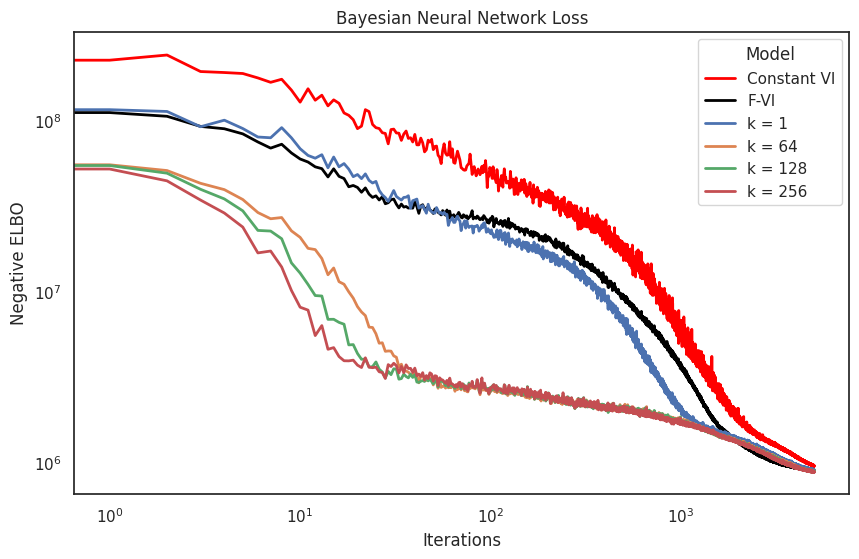

In [ ]:
n_width = len(args.nn_widths)
plotted_widths = np.array([1, 4, 16])
epochs = list(range(loss_all.shape[0]))

sns.set_theme(style="white")

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_all[:, n_width + 1], label='Constant VI', color='red', linewidth=2)
plt.plot(epochs, loss_all[:, n_width], label='F-VI', color='black', linewidth=2)

for i, width in enumerate(args.nn_widths):
    plt.plot(epochs, loss_all[:, i], label=f'k = {width}', linewidth=2)

plt.title("Bayesian Neural Network Loss")
plt.xlabel("Iterations")
plt.ylabel("Negative ELBO")
plt.yscale("log")
plt.xscale("log")

plt.legend(title="Model")

plt.savefig(f"{data_set}_elbo_BNN_{seed}.pdf")
plt.show()

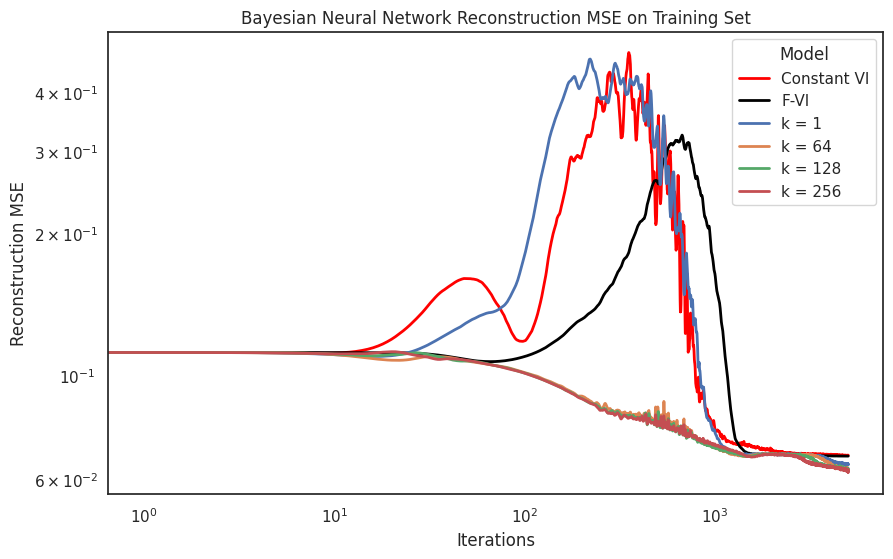

In [ ]:
n_width = len(args.nn_widths)
plotted_widths = np.array([1, 4, 16])
epochs = list(range(mse_all.shape[0]))

sns.set_theme(style="white")

plt.figure(figsize=(10, 6))
plt.plot(epochs, mse_all[:, n_width + 1], label='Constant VI', color='red', linewidth=2)
plt.plot(epochs, mse_all[:, n_width], label='F-VI', color='black', linewidth=2)

for i, width in enumerate(args.nn_widths):
    plt.plot(epochs, mse_all[:, i], label=f'k = {width}', linewidth=2)

plt.title("Bayesian Neural Network Reconstruction MSE on Training Set")
plt.xlabel("Iterations")
plt.ylabel("Reconstruction MSE")
plt.yscale("log")
plt.xscale("log")

plt.legend(title="Model")

plt.savefig(f"{data_set}_elbo_BNN_{seed}.pdf")
plt.show()

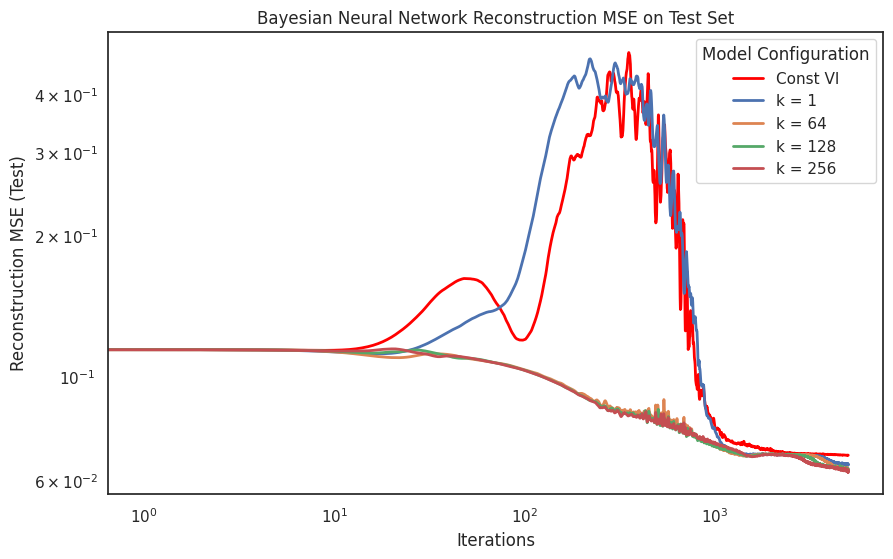

In [ ]:
n_width = len(args.nn_widths)
plotted_widths = np.array([1, 4, 16])

sns.set_theme(style="white")

plt.figure(figsize=(10, 6))

plt.plot(mse_test_all[:, n_width + 1], label='Const VI', color='red', linewidth=2)

for i, width in enumerate(args.nn_widths):
  plt.plot(mse_test_all[:, i], label=f'k = {width}', linewidth=2)

plt.title("Bayesian Neural Network Reconstruction MSE on Test Set")
plt.xlabel("Iterations")
plt.ylabel("Reconstruction MSE (Test)")
plt.xscale("log")
plt.yscale("log")

plt.legend(title="Model Configuration")

plt.savefig(f"{data_set}_mse_test_BNN_{seed}.pdf")
plt.show()

In [ ]:
def plot_metrics_for_all_seeds(init_seed, num_seeds, args, data_set):
    sns.set_theme(style="white")

    total_plots = num_seeds * 3
    n_width = len(args.nn_widths)

    plt.figure(figsize=(20, 30))

    for seed_index in range(num_seeds):
        seed = init_seed + seed_index

        loss_all = np.load(f"results_VAE/vae_{data_set}_loss_{seed}.npy")
        mse_all = np.load(f"results_VAE/vae_{data_set}_mse_{seed}.npy")
        mse_test_all = np.load(f"results_VAE/vae_{data_set}_mse_test_{seed}.npy")

        epochs = list(range(loss_all.shape[0]))

        # Plotting Negative ELBO
        plt.subplot(num_seeds, 3, seed_index * 3 + 1)
        plt.plot(epochs, loss_all[:, n_width + 1], label='Constant VI', color='red', linewidth=2)
        plt.plot(epochs, loss_all[:, n_width], label='F-VI', color='black', linewidth=2)
        for i, width in enumerate(args.nn_widths):
            plt.plot(epochs, loss_all[:, i], label=f'k = {width}', linewidth=2)
        plt.title(f"Seed {seed}: Bayesian Neural Network Loss")
        plt.xlabel("Iterations")
        plt.ylabel("Negative ELBO")
        plt.yscale("log")
        plt.xscale("log")
        plt.legend(title="Model")

        # Plotting Reconstruction MSE on Training Set
        plt.subplot(num_seeds, 3, seed_index * 3 + 2)
        plt.plot(epochs, mse_all[:, n_width + 1], label='Constant VI', color='red', linewidth=2)
        plt.plot(epochs, mse_all[:, n_width], label='F-VI', color='black', linewidth=2)
        for i, width in enumerate(args.nn_widths):
            plt.plot(epochs, mse_all[:, i], label=f'k = {width}', linewidth=2)
        plt.title(f"Seed {seed}: Reconstruction MSE on Training Set")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction MSE")
        plt.yscale("log")
        plt.xscale("log")
        plt.legend(title="Model")

        # Plotting Reconstruction MSE on Test Set
        plt.subplot(num_seeds, 3, seed_index * 3 + 3)
        plt.plot(epochs, mse_test_all[:, n_width + 1], label='Const VI', color='red', linewidth=2)
        for i, width in enumerate(args.nn_widths):
            plt.plot(epochs, mse_test_all[:, i], label=f'k = {width}', linewidth=2)
        plt.title(f"Seed {seed}: Reconstruction MSE on Test Set")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction MSE (Test)")
        plt.xscale("log")
        plt.yscale("log")
        plt.legend(title="Model Configuration")

    plt.tight_layout()
    plt.show()

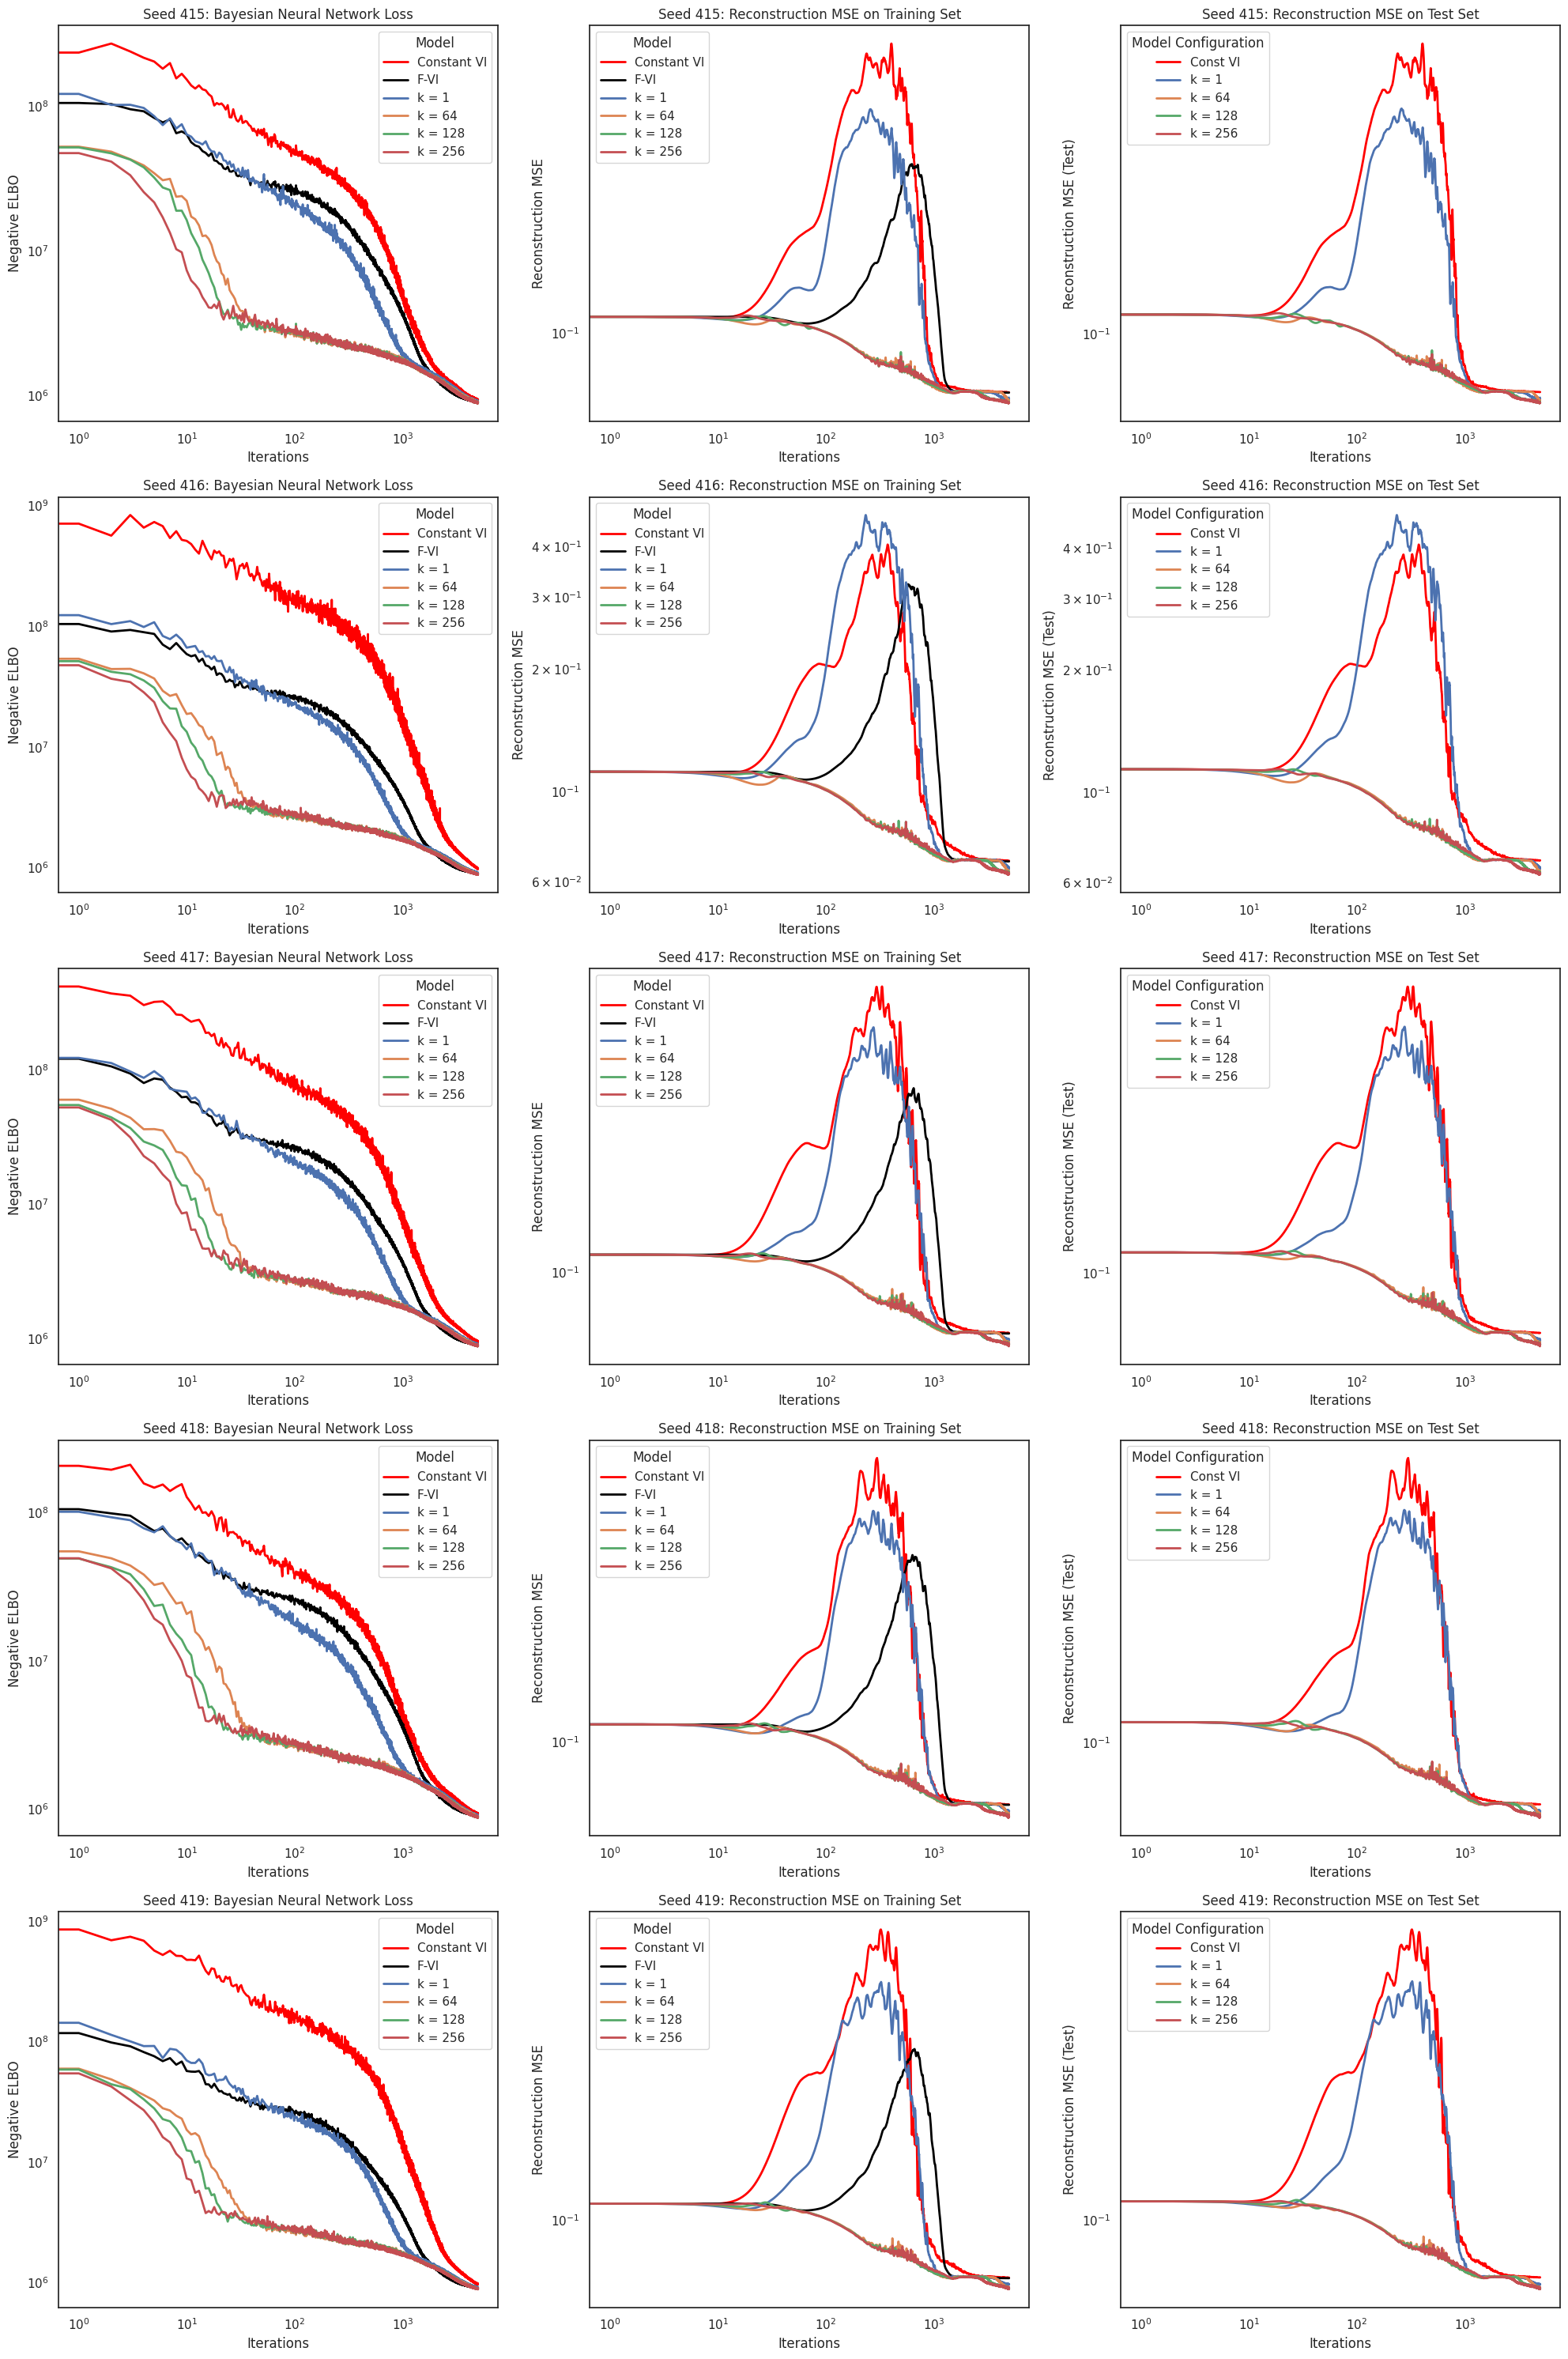

In [ ]:
plot_metrics_for_all_seeds(init_seed, 5, args, args.dataset)

## Computation Time

In [ ]:
# Plot computation time
def plot_iterations_to_tolerance(dataset, tol=0.07, init_seed=415, num_seed=5, n_algorithms=6):
    def Iter_to_tol(mse, tol, grid=1, min_epoch=0, max_epoch=5000):
        iteration = min_epoch
        error = tol + 1
        while (error > tol and iteration < (max_epoch - 1)):
            iteration += grid
            error = mse[iteration]

        return iteration

    exp_seed = [init_seed + i for i in range(num_seed)]

    iter_to_tol = np.empty((num_seed, n_algorithms))
    mse_final = np.empty((num_seed, n_algorithms))

    for i in range(num_seed):
        mse_all = np.load(f"results_VAE/vae_{data_set}_mse_{exp_seed[i]}.npy")

        for j in range(n_algorithms):
            iter_to_tol[i, j] = Iter_to_tol(mse_all[:, j], tol=tol)
            mse_final[i, j] = mse_all[-1, j]

    iter_to_tol = iter_to_tol[:, [4, 5, 0, 1, 2, 3]]
    algo_names = ["F-VI", "const"]
    algo_names += ["k=" + str(args.nn_widths[i]) for i in range(n_algorithms - 2)]

    plt.figure(figsize=(12,8))
    plt.boxplot(iter_to_tol, labels=algo_names, patch_artist=True,
                boxprops=dict(facecolor="red"), vert=False)
    plt.xscale("log")
    plt.grid(which='minor', visible='true', c='grey', alpha=0.25)
    plt.gca().invert_yaxis()

    plt.title("Bayesian Neural Network")
    plt.xlabel("Number of iterations to MSE<0.07")
    plt.show()

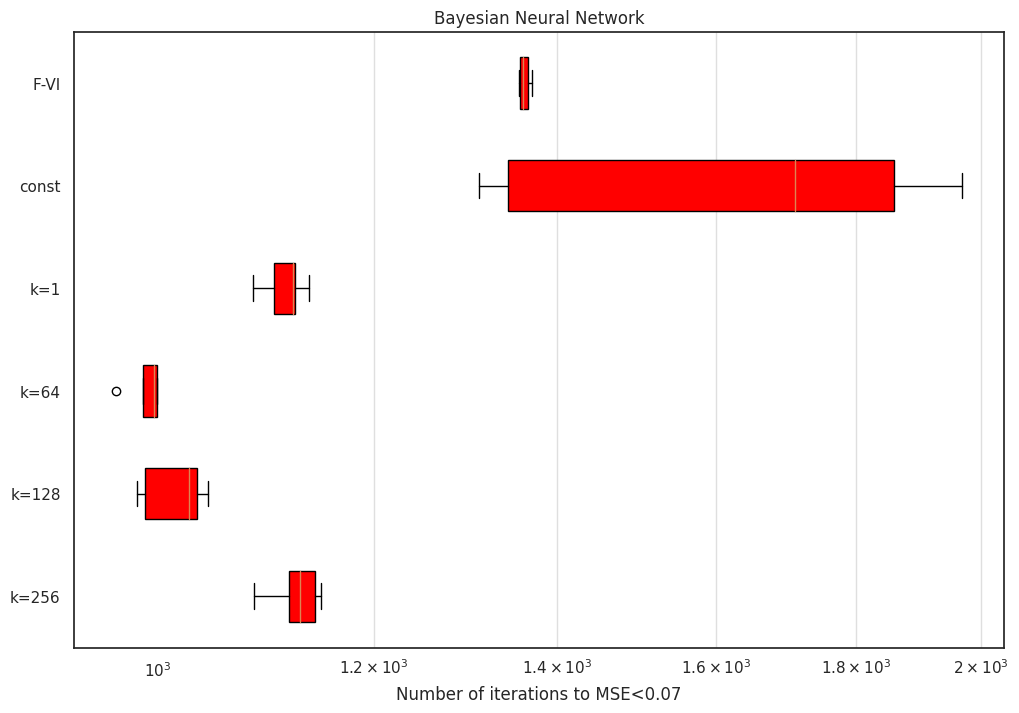

In [ ]:
plot_iterations_to_tolerance(args.dataset)